In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split

In [70]:
# Binary Classification using Linear and Logistic Regression

# X_test, y_pred : Simple model score
# X_test, y_test : X_test value internally test/train then score
# y_test, y_pred : classification
# Q Diff bw score and accuracy


In [71]:
x = np.random.random(30)
x

array([0.80692544, 0.85717869, 0.6412601 , 0.24079096, 0.74114033,
       0.53577878, 0.6511177 , 0.91729023, 0.08315955, 0.15697585,
       0.7549327 , 0.86613367, 0.85328444, 0.5076833 , 0.52720915,
       0.85096378, 0.09258003, 0.90025436, 0.63404279, 0.41532203,
       0.97431646, 0.56821009, 0.45877258, 0.66631892, 0.88223967,
       0.83633028, 0.32517342, 0.4563066 , 0.78073009, 0.22731767])

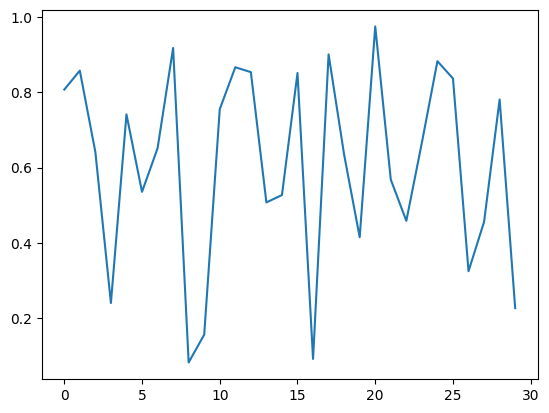

In [72]:
plt.plot(x)
plt.show()

In [73]:
# create sigmoid function

def sigmoid_fun(x):
    return (1 / (1 + 2.71 ** (-x)))

sigmoid_x = sigmoid_fun(x)

sigmoid_x

array([0.6909284 , 0.70152348, 0.65459597, 0.5597275 , 0.67675064,
       0.6304491 , 0.65681459, 0.71391833, 0.52071459, 0.53904456,
       0.6797513 , 0.70338946, 0.70070993, 0.6238998 , 0.6284564 ,
       0.70022451, 0.52305802, 0.71043699, 0.65296731, 0.60205973,
       0.7253872 , 0.6379497 , 0.61239072, 0.66022246, 0.70672847,
       0.69715325, 0.5803429 , 0.611807  , 0.68532392, 0.55641477])

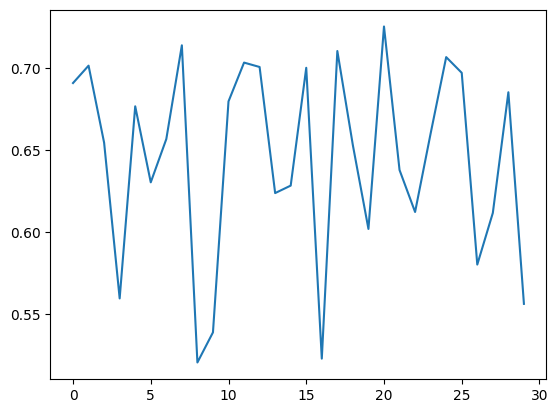

In [74]:
plt.plot(sigmoid_x)

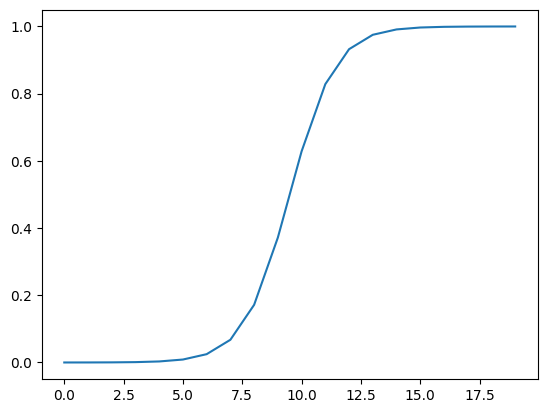

In [75]:
new_x = np.linspace(-10, 10, 20)
sigmoid_x_new = sigmoid_fun(new_x)
plt.plot(sigmoid_x_new)

In [76]:
df = pd.read_csv("myinsurance.csv")
df.head()

,Customer_ID,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
0,1,22,Male,25000,0,Single,0,0,1,No
1,2,25,Female,30000,0,Single,0,0,1,No
2,3,28,Male,35000,1,Single,0,0,1,No
3,4,30,Female,40000,1,Single,0,1,2,Yes
4,5,32,Male,45000,1,Single,0,1,2,Yes


In [77]:
df.shape

(100, 10)

In [78]:
df = df.drop(columns="Customer_ID")

In [79]:
df.shape

(100, 9)

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 100 non-null    int64 
 1   Gender              100 non-null    object
 2   Annual_Income       100 non-null    int64 
 3   Employment_Status   100 non-null    int64 
 4   Marital_Status      100 non-null    object
 5   Married             100 non-null    int64 
 6   Previous_Insurance  100 non-null    int64 
 7   Family_Size         100 non-null    int64 
 8   Buy_Insurance       100 non-null    object
dtypes: int64(6), object(3)
memory usage: 7.2+ KB


In [81]:
df.corr(numeric_only=True)

,Age,Annual_Income,Employment_Status,Married,Previous_Insurance,Family_Size
Age,1.000000,0.998332,0.650960,0.834590,0.960055,0.956927
Annual_Income,0.998332,1.000000,0.650526,0.839337,0.961360,0.957596
Employment_Status,0.650960,0.650526,1.000000,0.557578,0.610820,0.689424
Married,0.834590,0.839337,0.557578,1.000000,0.820608,0.848247
Previous_Insurance,0.960055,0.961360,0.610820,0.820608,1.000000,0.933681
Family_Size,0.956927,0.957596,0.689424,0.848247,0.933681,1.000000


In [82]:
# Convert object columns to string dtype
df[df.select_dtypes(include="object").columns] = \
    df.select_dtypes(include="object").astype("string")

# Now select string columns
text_data = list(df.select_dtypes(include="string").columns)

text_data

['Gender', 'Marital_Status', 'Buy_Insurance']

In [83]:
for i in text_data:
    print(f"Analysis Data {i}")
    display(df[i].value_counts())

Analysis Data Gender


Gender
Male      50
Female    50
Name: count, dtype: Int64

Analysis Data Marital_Status


Marital_Status
Married    51
Single     49
Name: count, dtype: Int64

Analysis Data Buy_Insurance


Buy_Insurance
Yes    69
No     31
Name: count, dtype: Int64

In [84]:
df["Gender"] = df["Gender"].replace({'Male' : 0, 'Female' : 1})
df

C:\Users\Harnoor kaur\AppData\Local\Temp\ipykernel_14780\4096947460.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Gender"] = df["Gender"].replace({'Male' : 0, 'Female' : 1})


,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
0,22,0,25000,0,Single,0,0,1,No
1,25,1,30000,0,Single,0,0,1,No
2,28,0,35000,1,Single,0,0,1,No
3,30,1,40000,1,Single,0,1,2,Yes
4,32,0,45000,1,Single,0,1,2,Yes
...,...,...,...,...,...,...,...,...,...
95,46,1,70000,1,Married,1,2,4,Yes
96,51,0,83000,1,Married,1,3,4,Yes
97,56,1,94000,1,Married,1,3,4,Yes
98,24,0,31000,0,Single,0,0,1,No


In [85]:
df["Marital_Status"] = df["Marital_Status"].replace({'Single' : 0, 'Married' : 1})

C:\Users\Harnoor kaur\AppData\Local\Temp\ipykernel_14780\3389318271.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Marital_Status"] = df["Marital_Status"].replace({'Single' : 0, 'Married' : 1})


In [86]:
df["Buy_Insurance"] = df["Buy_Insurance"].replace({'No' : 0, 'Yes' : 1})

C:\Users\Harnoor kaur\AppData\Local\Temp\ipykernel_14780\3133920246.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Buy_Insurance"] = df["Buy_Insurance"].replace({'No' : 0, 'Yes' : 1})


In [87]:
df.corr().round(2)

,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
Age,1.00,0.02,1.00,0.65,0.83,0.83,0.96,0.96,0.73
Gender,0.02,1.00,0.02,-0.02,-0.02,-0.02,0.02,0.01,0.02
Annual_Income,1.00,0.02,1.00,0.65,0.84,0.84,0.96,0.96,0.73
Employment_Status,0.65,-0.02,0.65,1.00,0.56,0.56,0.61,0.69,0.82
Marital_Status,0.83,-0.02,0.84,0.56,1.00,1.00,0.82,0.85,0.68
Married,0.83,-0.02,0.84,0.56,1.00,1.00,0.82,0.85,0.68
Previous_Insurance,0.96,0.02,0.96,0.61,0.82,0.82,1.00,0.93,0.75
Family_Size,0.96,0.01,0.96,0.69,0.85,0.85,0.93,1.00,0.77
Buy_Insurance,0.73,0.02,0.73,0.82,0.68,0.68,0.75,0.77,1.00


In [88]:
X = df.drop(columns=  "Buy_Insurance")
y = df["Buy_Insurance"]

In [89]:
X.shape

(100, 8)

In [91]:
y.shape

(100,)

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [93]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80, 8)
(20, 8)
(80,)
(20,)


In [94]:
model = LinearRegression()
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [95]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [96]:
y_pred = model.predict(X_test)
y_pred

array([ 0.71072184,  1.12604542,  0.9805892 ,  0.9277091 ,  0.85674055,
        0.97519146,  0.79790808,  0.88099038, -0.16123934,  0.01860019,
       -0.0217355 ,  1.01000544, -0.02670258, -0.00486368,  0.01102285,
        0.77736299,  0.78936777,  1.09662918,  0.79585977,  1.01692078])

In [97]:
y_test 

83    0
53    1
70    1
45    1
44    1
39    1
22    1
80    1
10    0
0     0
18    0
30    1
73    0
33    0
90    0
4     1
76    1
77    1
12    1
31    1
Name: Buy_Insurance, dtype: int64

In [98]:
sigmoid_fun(y_pred)

array([0.67008138, 0.75447242, 0.72663116, 0.71603505, 0.70143202,
       0.72556093, 0.68900536, 0.70647026, 0.45989948, 0.50463572,
       0.49458292, 0.73241765, 0.49334512, 0.49878779, 0.50274728,
       0.68459955, 0.68717802, 0.74899942, 0.68856763, 0.73376663])